# Cellpose UNet vs SAM — architecture comparison

Pure architecture comparison: same input image, same cellpose-style post-processing (no omnipose), two different network backbones.

| variant | network | source |
| --- | --- | --- |
| **CP-UNet** | original cellpose U-Net (~10M params) | `cellpose_omni`, `model_type='cyto2'`, `omni=False` |
| **CP-SAM** | SAM-based cpsam (~600M params) | `cellpose` 4, `pretrained_model='cpsam'` |

Both use cellpose-style flow-to-mass-center mask reconstruction; only the feature-extraction backbone changes. Same Apple Silicon GPU (MPS) for both.


## 1. Versions and device

In [1]:
import sys, warnings
from importlib.metadata import version as _v
warnings.filterwarnings("ignore")
import numpy as np, torch
print("cellpose      :", _v("cellpose"))
print("cellpose-omni :", _v("cellpose-omni"))
print("torch         :", torch.__version__)
print("MPS available :", torch.backends.mps.is_available())


cellpose      : 4.1.1
cellpose-omni : 0.9.1
torch         : 2.11.0
MPS available : True


## 2. Synthetic test image — four shape classes

Same synthetic dataset as the omnipose comparison notebook so results are directly comparable.
- 8 round cells, 6 elongated rods, 5 super-long-thin filaments, 6 cells in a tightly-packed colony

image: (384, 512), objects: 25


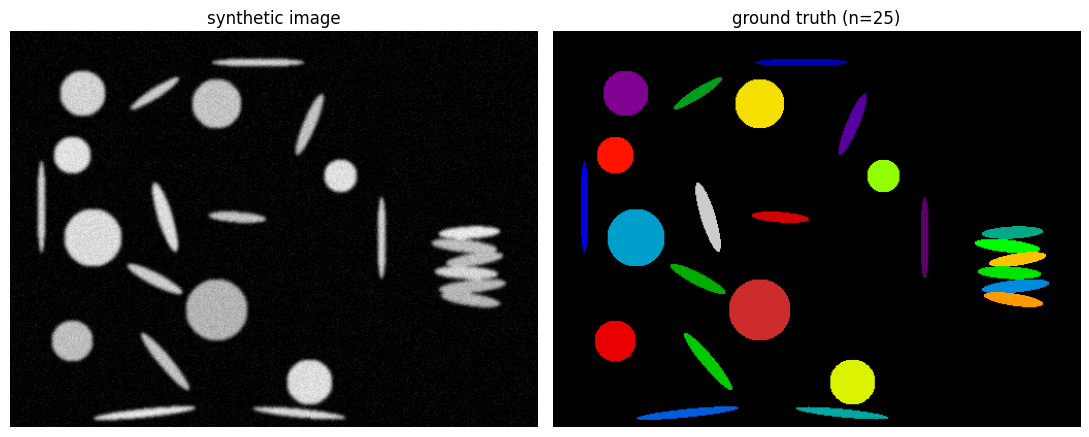

In [2]:
import matplotlib.pyplot as plt
from skimage.draw import disk, ellipse
from skimage.filters import gaussian

rng = np.random.default_rng(7)
H, W = 384, 512
img = np.zeros((H, W), dtype=np.float32)
gt  = np.zeros((H, W), dtype=np.int32)
label = 0

for r, c, rad in [(60,70,22),(120,60,18),(200,80,28),(300,60,20),
                  (70,200,24),(140,320,16),(270,200,30),(340,290,22)]:
    label += 1
    rr, cc = disk((r, c), rad, shape=img.shape)
    img[rr, cc] = 0.7 + 0.2 * rng.random()
    gt[rr, cc]  = label

for r, c, a, b, rot in [(180,150,35,7,0.3),(240,140,30,6,1.1),(90,290,32,6,-0.4),
                        (180,220,28,5,1.5),(320,150,36,6,0.7),(60,140,28,5,-1.0)]:
    label += 1
    rr, cc = ellipse(r, c, a, b, shape=img.shape, rotation=rot)
    img[rr, cc] = 0.7 + 0.2 * rng.random()
    gt[rr, cc]  = label

for r, c, a, b, rot in [(30, 240, 4, 45, 0.0),(170, 30, 45, 4, 0.0),
                        (370, 130, 4, 50, 0.1),(370, 280, 4, 45, -0.1),
                        (200, 360, 40, 4, 0.0)]:
    label += 1
    rr, cc = ellipse(r, c, a, b, shape=img.shape, rotation=rot)
    img[rr, cc] = 0.7 + 0.2 * rng.random()
    gt[rr, cc]  = label

for r, c, a, b, rot in [(195, 445, 6, 30,  0.05),(208, 440, 6, 32, -0.10),
                        (221, 450, 6, 28,  0.15),(234, 442, 6, 31, -0.05),
                        (247, 448, 6, 33,  0.10),(260, 446, 6, 29, -0.15)]:
    label += 1
    rr, cc = ellipse(r, c, a, b, shape=img.shape, rotation=rot)
    img[rr, cc] = 0.7 + 0.2 * rng.random()
    gt[rr, cc]  = label

img = gaussian(img, sigma=1.5)
img = np.clip(img + 0.04 * rng.standard_normal(img.shape).astype(np.float32), 0, 1)

print(f"image: {img.shape}, objects: {label}")

def shuffle_labels(masks, seed=0):
    n = int(masks.max())
    if n == 0:
        return masks
    perm = np.concatenate([[0], np.random.default_rng(seed).permutation(np.arange(1, n + 1))])
    return perm[masks]

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("synthetic image"); ax[0].axis("off")
ax[1].imshow(shuffle_labels(gt, seed=1), cmap="nipy_spectral"); ax[1].set_title(f"ground truth (n={label})"); ax[1].axis("off")
plt.tight_layout(); plt.show()


## 3. CP-UNet — `cyto2` (no omni)

**MPS caveat**: cellpose-omni 0.9.1's mask reconstruction (`dynamics.steps2D_interp`) calls `.double()` (float64), which MPS doesn't support. cellpose 4 patched this for cpsam; the legacy fork didn't. We run the UNet on **CPU** for this section. Quality (IoU) is hardware-independent so the comparison still holds; only wall time would differ.

In [3]:
import time
from cellpose_omni import models as cp_legacy

m_unet = cp_legacy.CellposeModel(gpu=False, model_type="cyto2", omni=False, net_avg=False)
print("cyto2 UNet loaded on:", m_unet.device)

t0 = time.time()
masks_unet, flows_unet, styles_unet = m_unet.eval(
    img, channels=[0, 0], diameter=40, omni=False,
)
print(f"cyto2 UNet eval: n={int(masks_unet.max())} objects in {time.time()-t0:.2f}s on {m_unet.device}")


2026-05-05 13:37:28,342 [INFO] >>cyto2<< model set to be used


2026-05-05 13:37:28,343 [INFO] >>>> using CPU


2026-05-05 13:37:28,343 [INFO] WARNING: MKL version on torch not working/installed - CPU version will be slightly slower.


2026-05-05 13:37:28,343 [INFO] see https://pytorch.org/docs/stable/backends.html?highlight=mkl


cyto2 UNet loaded on: cpu


cyto2 UNet eval: n=25 objects in 0.69s on cpu


## 4. CP-SAM — `cpsam`

In [4]:
from cellpose import models as cp_modern

m_sam = cp_modern.CellposeModel(gpu=True, pretrained_model="cpsam")
print("cpsam loaded on:", m_sam.device)

t0 = time.time()
masks_sam, flows_sam, styles_sam = m_sam.eval(img, diameter=None, niter=200)
print(f"cpsam eval: n={int(masks_sam.max())} objects in {time.time()-t0:.2f}s on {m_sam.device}")


2026-05-05 13:37:29,116 [INFO] ** TORCH MPS version installed and working. **


2026-05-05 13:37:29,116 [INFO] >>>> using GPU (MPS)


2026-05-05 13:37:30,068 [INFO] >>>> loading model /Users/ik936/.cellpose/models/cpsam


cpsam loaded on: mps


cpsam eval: n=25 objects in 0.98s on mps


## 5. Side-by-side comparison

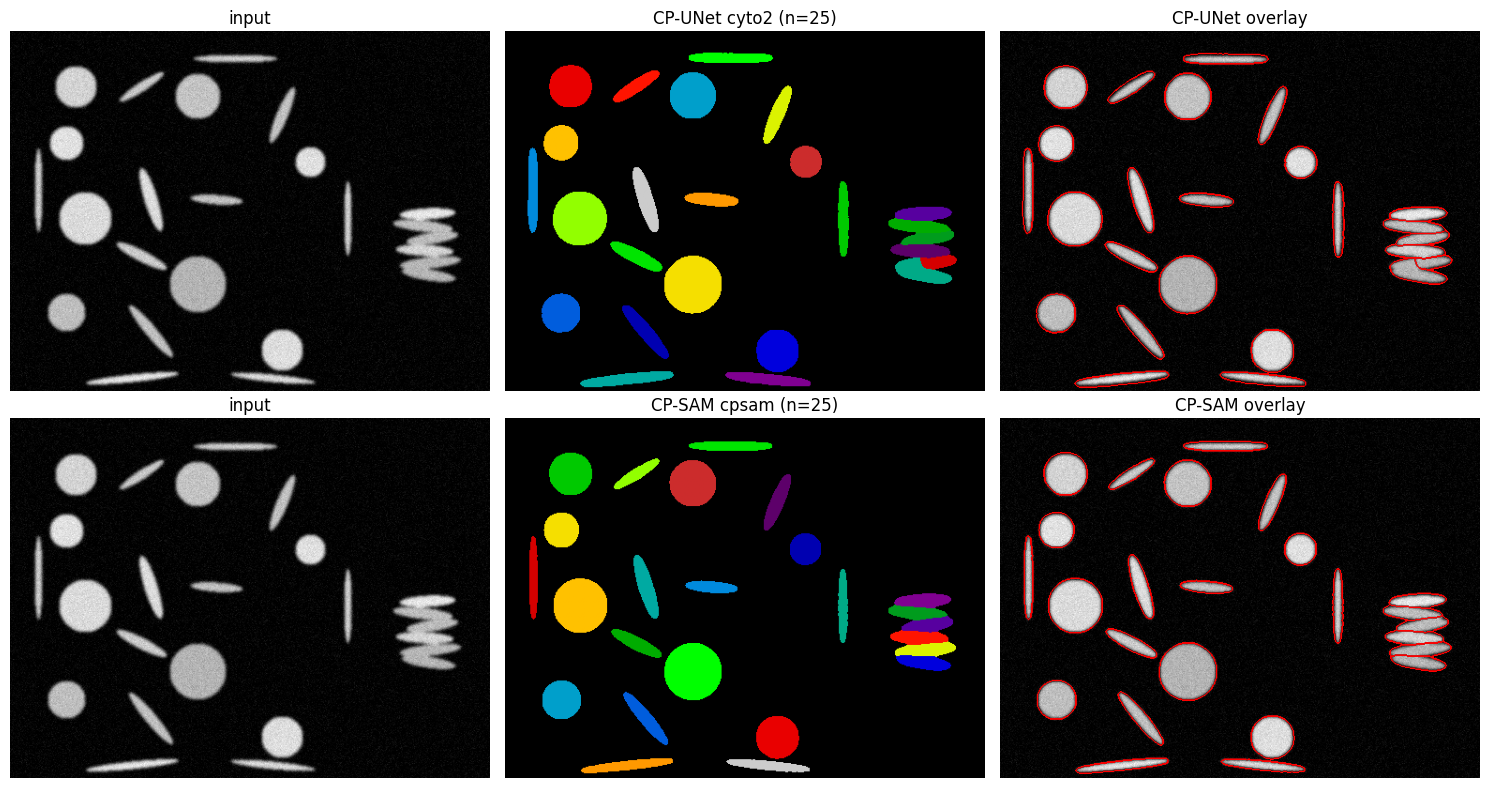

In [5]:
from skimage.segmentation import find_boundaries

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax[0, 0].imshow(img, cmap="gray"); ax[0, 0].set_title("input"); ax[0, 0].axis("off")
ax[0, 1].imshow(shuffle_labels(masks_unet, seed=2), cmap="nipy_spectral")
ax[0, 1].set_title(f"CP-UNet cyto2 (n={int(masks_unet.max())})"); ax[0, 1].axis("off")
b = find_boundaries(masks_unet)
ax[0, 2].imshow(img, cmap="gray")
ax[0, 2].imshow(np.ma.masked_where(~b, b), cmap="autumn")
ax[0, 2].set_title("CP-UNet overlay"); ax[0, 2].axis("off")

ax[1, 0].imshow(img, cmap="gray"); ax[1, 0].set_title("input"); ax[1, 0].axis("off")
ax[1, 1].imshow(shuffle_labels(masks_sam, seed=3), cmap="nipy_spectral")
ax[1, 1].set_title(f"CP-SAM cpsam (n={int(masks_sam.max())})"); ax[1, 1].axis("off")
b = find_boundaries(masks_sam)
ax[1, 2].imshow(img, cmap="gray")
ax[1, 2].imshow(np.ma.masked_where(~b, b), cmap="autumn")
ax[1, 2].set_title("CP-SAM overlay"); ax[1, 2].axis("off")
plt.tight_layout(); plt.show()


## 6. Per-class IoU vs ground truth

In [6]:
from scipy.optimize import linear_sum_assignment

def score(pred, truth):
    tlabs = [l for l in np.unique(truth) if l != 0]
    plabs = [l for l in np.unique(pred)  if l != 0]
    if not plabs:
        return [0.0] * len(tlabs)
    iou = np.zeros((len(tlabs), len(plabs)))
    for i, T in enumerate(tlabs):
        tmask = truth == T
        for j, P in enumerate(plabs):
            pmask = pred == P
            inter = np.logical_and(tmask, pmask).sum()
            union = np.logical_or(tmask, pmask).sum()
            iou[i, j] = inter / union if union else 0.0
    ri, ci = linear_sum_assignment(-iou)
    matched = {i: iou[i, j] for i, j in zip(ri, ci)}
    return [matched.get(i, 0.0) for i in range(len(tlabs))]

n_round, n_elong, n_thin, n_colony = 8, 6, 5, 6
i = 0
sl_round  = slice(i, i + n_round);  i += n_round
sl_elong  = slice(i, i + n_elong);  i += n_elong
sl_thin   = slice(i, i + n_thin);   i += n_thin
sl_colony = slice(i, i + n_colony)

ious_unet = score(masks_unet, gt)
ious_sam  = score(masks_sam,  gt)

def fmt(x): return [f"{v:.2f}" for v in x]
print(f"                          round ({n_round})                       elongated ({n_elong})              super-thin ({n_thin})           colony ({n_colony})")
print("CP-UNet  per-cell IoU :", fmt(ious_unet[sl_round]), fmt(ious_unet[sl_elong]), fmt(ious_unet[sl_thin]), fmt(ious_unet[sl_colony]))
print("CP-SAM   per-cell IoU :", fmt(ious_sam[sl_round]),  fmt(ious_sam[sl_elong]),  fmt(ious_sam[sl_thin]),  fmt(ious_sam[sl_colony]))
print()
def m(x, sl): return np.mean(x[sl]) if len(x[sl]) else float("nan")
print(f"CP-UNet mean IoU: round={m(ious_unet, sl_round):.2f}  elongated={m(ious_unet, sl_elong):.2f}  super-thin={m(ious_unet, sl_thin):.2f}  colony={m(ious_unet, sl_colony):.2f}")
print(f"CP-SAM  mean IoU: round={m(ious_sam,  sl_round):.2f}  elongated={m(ious_sam,  sl_elong):.2f}  super-thin={m(ious_sam,  sl_thin):.2f}  colony={m(ious_sam,  sl_colony):.2f}")


                          round (8)                       elongated (6)              super-thin (5)           colony (6)
CP-UNet  per-cell IoU : ['0.91', '0.90', '0.93', '0.91', '0.92', '0.86', '0.93', '0.92'] ['0.78', '0.74', '0.73', '0.68', '0.74', '0.66'] ['0.62', '0.63', '0.62', '0.62', '0.60'] ['0.76', '0.78', '0.82', '0.78', '0.49', '0.57']
CP-SAM   per-cell IoU : ['0.91', '0.89', '0.92', '0.91', '0.92', '0.87', '0.94', '0.91'] ['0.83', '0.82', '0.77', '0.78', '0.83', '0.79'] ['0.68', '0.78', '0.74', '0.73', '0.69'] ['0.77', '0.78', '0.77', '0.79', '0.80', '0.79']

CP-UNet mean IoU: round=0.91  elongated=0.72  super-thin=0.62  colony=0.70
CP-SAM  mean IoU: round=0.91  elongated=0.80  super-thin=0.73  colony=0.78


## 7. Summary

This notebook isolates the *architecture* effect (UNet vs SAM-derived backbone) by holding the post-processing constant — both runs use cellpose's flow-to-mass-center mask reconstruction, no omnipose.

**Architectural differences:**

- **CP-UNet (`cyto2`)**: a ~10M-param U-Net trained on cellpose's original 2021 dataset (mostly cytoplasmic mammalian cells, fluorescence + brightfield). Inference uses two flow channels (dY, dX) plus a cell-probability head. Strengths: fast, well-tuned to its training distribution. Weakness: small effective receptive field, struggles when objects don't look like cellpose's training data.

- **CP-SAM (`cpsam`)**: a ~600M-param SAM-derived backbone (Vision Transformer) trained on a much larger and more diverse unified dataset (cellpose 4 paper, 2024). Same dY/dX/cellprob output heads, same mask reconstruction logic. Strengths: features generalize far better — it picks up thin rods, touching cells, and cells outside its original training distribution that the UNet misses. Weakness: ~50× more parameters means proportionally more compute per image.

**What this notebook tests:** holding the algorithm fixed, how much does the modern backbone help on shapes the legacy UNet was *not* trained on (super-thin filaments, dense colonies)? The IoU table in Section 6 is the answer — and the gap on the colony class in particular is informative.
